# AWGN versus Rayleigh fading

This notebook compares all modulation schemes implemented by `pyberlab` over two channel models: additive white Gaussian noise (AWGN) and independent Rayleigh flat fading. It combines reproducible Monte-Carlo results with the package's analytical or numerical BER baselines.

## Channel assumptions

The AWGN channel adds circular Gaussian noise at a specified $E_b/N_0$. The Rayleigh model additionally multiplies every symbol by an independent complex Gaussian fading coefficient. The receiver is assumed to know that coefficient perfectly and performs coherent equalisation before hard decisions.

This isolates the fading penalty under ideal channel knowledge. It does **not** model channel-estimation error, time correlation, pulse shaping, synchronisation, coding, or frequency-selective multipath.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "pyberlab").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the pyberlab repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pyberlab.channel import awgn, rayleigh
from pyberlab.modulation import BPSK, PSK8, QAM16, QAM64, QPSK
from pyberlab.simulation import run_simulation

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = OUTPUT_DIR / "awgn_vs_rayleigh_all_modulations.png"

MODULATIONS = {
    "BPSK": BPSK(),
    "QPSK": QPSK(),
    "8-PSK": PSK8(),
    "16-QAM": QAM16(),
    "64-QAM": QAM64(),
}
CHANNELS = {"AWGN": awgn, "Rayleigh": rayleigh}
EBN0_DB = np.arange(0, 17, 2)
BASE_SEED = 2026
TARGET_BER = 5e-2

print(f"Running {len(MODULATIONS) * len(CHANNELS)} reproducible experiments")
print(f"Eb/N0 grid: {EBN0_DB.tolist()} dB")

Running 10 reproducible experiments
Eb/N0 grid: [0, 2, 4, 6, 8, 10, 12, 14, 16] dB


## Run the experiment matrix

Every modulation/channel combination receives a deterministic seed and its own CSV file. The 500,000-bit cap keeps this comparison suitable for interactive use. At high SNR, simulated BER may be zero because no errors were observed before the cap; the theoretical curve remains available in that region.

In [3]:
results = {}
for modulation_index, (modulation_name, modulator) in enumerate(MODULATIONS.items()):
    for channel_index, (channel_name, channel_fn) in enumerate(CHANNELS.items()):
        seed = BASE_SEED + 10 * modulation_index + channel_index
        csv_name = f"{modulation_name.lower().replace('-', '')}_{channel_name.lower()}.csv"
        print(f"Running {modulation_name:>6} over {channel_name:<8} ...")
        results[(modulation_name, channel_name)] = run_simulation(
            modulator,
            channel_fn,
            EBN0_DB,
            seed=seed,
            min_errors=150,
            max_bits=500_000,
            csv_path=OUTPUT_DIR / csv_name,
        )

print("All experiments completed.")

Running   BPSK over AWGN     ...
Running   BPSK over Rayleigh ...
Running   QPSK over AWGN     ...
Running   QPSK over Rayleigh ...
Running  8-PSK over AWGN     ...
Running  8-PSK over Rayleigh ...
Running 16-QAM over AWGN     ...
Running 16-QAM over Rayleigh ...
Running 64-QAM over AWGN     ...
Running 64-QAM over Rayleigh ...
All experiments completed.


In [4]:
print(f"{'Modulation':>10} {'Channel':>10} {'total bits':>14} {'total errors':>14}")
print("-" * 54)
for (modulation_name, channel_name), result in results.items():
    print(
        f"{modulation_name:>10} {channel_name:>10} "
        f"{sum(result['n_bits']):14,d} {sum(result['n_errors']):14,d}"
    )

Modulation    Channel     total bits   total errors
------------------------------------------------------
      BPSK       AWGN      2,900,000         13,309
      BPSK   Rayleigh        900,000         47,229
      QPSK       AWGN      2,900,000         13,026
      QPSK   Rayleigh        900,000         47,463
     8-PSK       AWGN      2,148,297         27,946
     8-PSK   Rayleigh        899,991         65,149
    16-QAM       AWGN      2,100,000         33,948
    16-QAM   Rayleigh        900,000         73,155
    64-QAM       AWGN      1,299,966         65,289
    64-QAM   Rayleigh        899,964        106,283


## Compare BER curves

The two panels share the same axes and colour assignment. Solid lines with markers are Monte-Carlo estimates; dashed lines are theory. BPSK and QPSK overlap because they have the same BER at equal $E_b/N_0$.

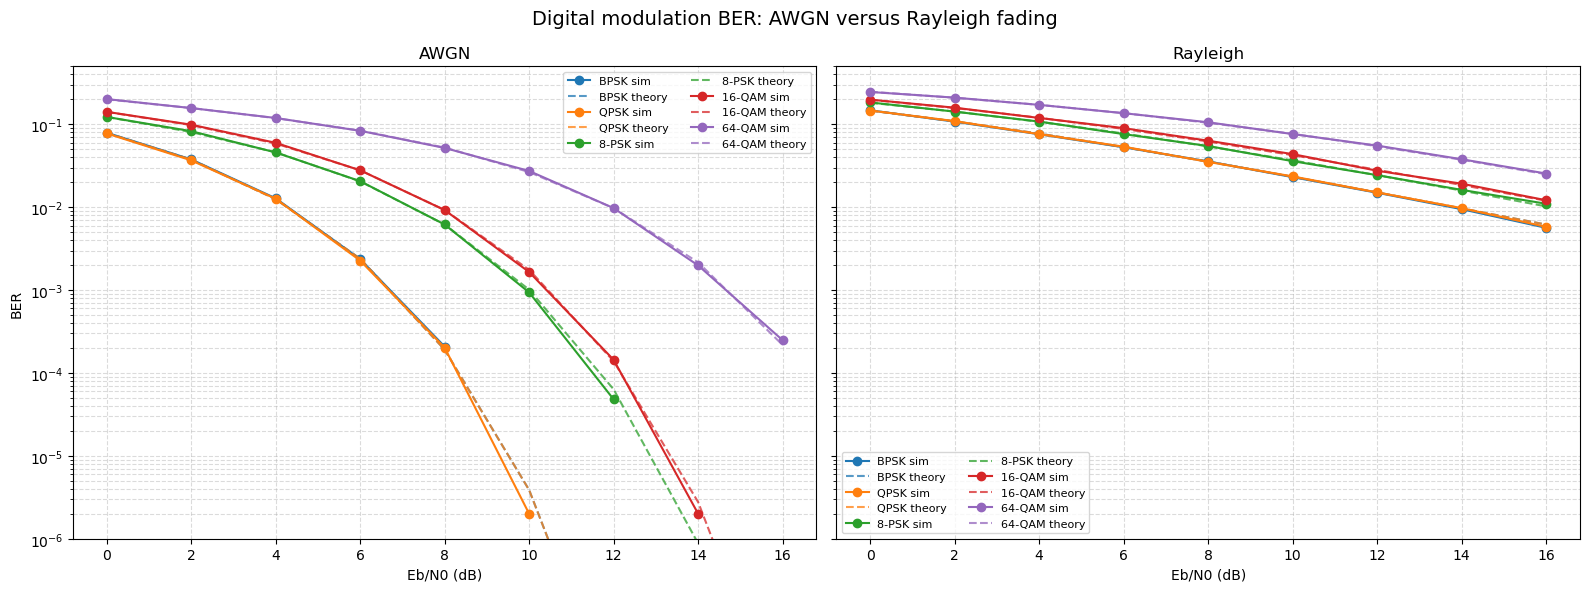

Saved figure to outputs\awgn_vs_rayleigh_all_modulations.png


In [5]:
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colour_by_modulation = dict(zip(MODULATIONS, colours))
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, channel_name in zip(axes, CHANNELS):
    for modulation_name in MODULATIONS:
        result = results[(modulation_name, channel_name)]
        ebn0 = np.asarray(result["EbN0_dB"])
        simulated = np.asarray(result["ber_sim"])
        theoretical = np.asarray(result["ber_theory"])
        simulated_for_plot = np.where(simulated > 0, simulated, np.nan)
        colour = colour_by_modulation[modulation_name]
        ax.semilogy(ebn0, simulated_for_plot, "o-", color=colour, label=f"{modulation_name} sim")
        ax.semilogy(ebn0, theoretical, "--", color=colour, alpha=0.75, label=f"{modulation_name} theory")
    ax.set(title=channel_name, xlabel="Eb/N0 (dB)", ylim=(1e-6, 0.5))
    ax.grid(True, which="both", linestyle="--", alpha=0.45)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel("BER")
fig.suptitle("Digital modulation BER: AWGN versus Rayleigh fading", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=150)
plt.show()
print(f"Saved figure to {FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Estimate the fading penalty

For a compact numerical comparison, interpolate the theoretical curves in log-BER space and estimate the $E_b/N_0$ required to reach BER $=5\times10^{-2}$. The 2 dB grid makes these values approximate, but the difference clearly shows the Rayleigh penalty.

In [6]:
def ebn0_at_target(result: dict, target_ber: float) -> float:
    ebn0 = np.asarray(result["EbN0_dB"], dtype=float)
    ber = np.asarray(result["ber_theory"], dtype=float)
    if not ber[-1] <= target_ber <= ber[0]:
        return float("nan")
    return float(np.interp(np.log10(target_ber), np.log10(ber[::-1]), ebn0[::-1]))


print(f"Target BER: {TARGET_BER:.0e}")
print(f"{'Modulation':>10} {'AWGN dB':>10} {'Rayleigh dB':>13} {'penalty dB':>12}")
print("-" * 49)
for modulation_name in MODULATIONS:
    awgn_required = ebn0_at_target(results[(modulation_name, "AWGN")], TARGET_BER)
    rayleigh_required = ebn0_at_target(results[(modulation_name, "Rayleigh")], TARGET_BER)
    penalty = rayleigh_required - awgn_required
    print(f"{modulation_name:>10} {awgn_required:10.2f} {rayleigh_required:13.2f} {penalty:12.2f}")

Target BER: 5e-02
Modulation    AWGN dB   Rayleigh dB   penalty dB
-------------------------------------------------
      BPSK       1.22          6.29         5.07
      QPSK       1.22          6.29         5.07
     8-PSK       3.70          8.41         4.71
    16-QAM       4.43          9.13         4.70
    64-QAM       8.13         12.45         4.31


## Interpretation

AWGN curves fall rapidly because every symbol experiences the same average signal energy. Under Rayleigh fading, occasional deep fades dominate the error probability, producing a much slower high-SNR decay even with perfect channel knowledge.

Higher-order schemes generally require more $E_b/N_0$ for the same BER because their decision regions are closer together. BPSK and QPSK are the most robust schemes here, while 64-QAM provides greater spectral efficiency at the cost of noise and fading sensitivity.

### Suggested experiments

- Increase `max_bits` to improve high-SNR Monte-Carlo estimates.
- Change `TARGET_BER` and extend the SNR grid when the target lies outside a curve.
- Compare results at equal symbol rate rather than equal energy per bit.
- Introduce channel-estimation error to test the ideal coherent-equalisation assumption.